# Surprise Model — Test with a Clearly Surprising Trajectory

This notebook constructs a trajectory that deliberately violates **both** movement and state priors at the subgoal location, then checks that `infer_subgoal` recovers the correct subgoal.

## Why the trajectory is surprising

The surprise model has two priors:

| Prior | Expects |
|-------|--------|
| **Movement prior** | Agent continues in the same direction (forward > lateral > backward) |
| **State prior** | Agent moves toward the candidate subgoal (Manhattan-distance decay) |

The test trajectory does the following:
1. Moves efficiently from **Start → Subgoal** (unsurprising, consistent with both priors)
2. At the **Subgoal**, oscillates back-and-forth **twice** before leaving (both priors are violated: backward step + moving away from terminal)
3. Moves efficiently from **Subgoal → Terminal** (unsurprising again)

The oscillation at the subgoal maximises Shannon surprise `h(a) = −log₂ p(a)` for those steps because the backward action has lowest prior probability. Multiplied by a positive reward (being near the subgoal), those steps have the highest expected value under the surprise model — so the model assigns maximum log-likelihood to the true subgoal.

---

**Grid:** 7 × 7, no walls  
**Coordinate system:** MDP coords `(x, y_mdp)` — `y=0` is bottom row

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# ── Path setup ────────────────────────────────────────────────────────────────
ALGO_DIR = Path('..').resolve()          # algorithms/
sys.path.insert(0, str(ALGO_DIR))

from surprise_v1 import (
    infer_subgoal,
    trajectory_log_likelihood,
    DEFAULT_PARAMS,
    ACTIONS, ACTION_DELTA, OPPOSITE,
)

print('Imports OK')
print(f'DEFAULT_PARAMS (λ, γ, α, τ, ε) = {DEFAULT_PARAMS}')

Imports OK
DEFAULT_PARAMS (λ, γ, α, τ, ε) = (0.1, 2.14, 1.84, 6.93, 0.39)


/opt/anaconda3/envs/msc/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── Test scenario ─────────────────────────────────────────────────────────────
#
# All positions are MDP coords (x, y_mdp) where y=0 = bottom row.
#
#  y=6  .  .  .  .  .  .  .
#  y=5  .  .  .  .  .  G  .     G = terminal (5, 5)
#  y=4  .  .  C  .  .  .  .     C = true subgoal / coin (2, 4)
#  y=3  .  .  .  .  .  .  .
#  y=2  .  .  .  .  .  .  .
#  y=1  .  S  .  .  .  .  .     S = agent start (1, 1)
#  y=0  .  .  .  .  .  .  .
#       x=0 1  2  3  4  5  6

GRID_SIZE = 7
START     = (1, 1)   # MDP coords
SUBGOAL   = (2, 4)   # true coin / subgoal
TERMINAL  = (5, 5)   # known goal

# ── Trajectory construction ───────────────────────────────────────────────────
#
# Phase 1 — efficient approach to subgoal (greedy, no surprises)
#   (1,1) -E-> (2,1) -N-> (2,2) -N-> (2,3) -N-> (2,4)  ← arrives at subgoal
#
# Phase 2 — SURPRISING oscillation at subgoal (violates both priors)
#   (2,4) -S-> (2,3)   ← backward: against movement prior (forward was N)
#   (2,3) -N-> (2,4)   ← return
#   (2,4) -S-> (2,3)   ← backward again
#   (2,3) -N-> (2,4)   ← return
#
# Phase 3 — efficient approach to terminal (no surprises)
#   (2,4) -E-> (3,4) -E-> (4,4) -N-> (4,5) -E-> (5,5)  ← terminal

TRAJECTORY = [
    # Phase 1: start → subgoal (efficient)
    ((1, 1), 'E'),
    ((2, 1), 'N'),
    ((2, 2), 'N'),
    ((2, 3), 'N'),   # next step arrives at subgoal (2,4)
    # Phase 2: oscillation at subgoal (surprising)
    ((2, 4), 'S'),   # ← violates movement prior (expected N) and state prior
    ((2, 3), 'N'),
    ((2, 4), 'S'),   # ← second backward step
    ((2, 3), 'N'),
    # Phase 3: subgoal → terminal (efficient)
    ((2, 4), 'E'),
    ((3, 4), 'E'),
    ((4, 4), 'N'),
    ((4, 5), 'E'),   # next step arrives at terminal (5,5)
]

# Label which steps are 'surprising' (backward / anti-prior moves at subgoal)
SURPRISING_STEPS = {4, 6}   # 0-indexed: the two 'S' actions at the subgoal

print(f'Trajectory length: {len(TRAJECTORY)} steps')
print(f'Start: {START}  |  True subgoal: {SUBGOAL}  |  Terminal: {TERMINAL}')
print()
print('  Step  Position   Action  Note')
print('  ----  ---------  ------  ----')
for i, (pos, act) in enumerate(TRAJECTORY):
    note = '← SURPRISING (backward, away from terminal)' if i in SURPRISING_STEPS else ''
    print(f'  {i:>4}  {str(pos):<9}  {act:<6}  {note}')

Trajectory length: 12 steps
Start: (1, 1)  |  True subgoal: (2, 4)  |  Terminal: (5, 5)

  Step  Position   Action  Note
  ----  ---------  ------  ----
     0  (1, 1)     E       
     1  (2, 1)     N       
     2  (2, 2)     N       
     3  (2, 3)     N       
     4  (2, 4)     S       ← SURPRISING (backward, away from terminal)
     5  (2, 3)     N       
     6  (2, 4)     S       ← SURPRISING (backward, away from terminal)
     7  (2, 3)     N       
     8  (2, 4)     E       
     9  (3, 4)     E       
    10  (4, 4)     N       
    11  (4, 5)     E       


In [4]:
# ── Run surprise model ────────────────────────────────────────────────────────

# Candidates: all cells except terminal and start
candidates = [
    (x, y)
    for x in range(GRID_SIZE)
    for y in range(GRID_SIZE)
    if (x, y) != TERMINAL and (x, y) != START
]

# infer_subgoal expects a list-of-trajectories
ll_grid, predicted = infer_subgoal(
    trajectories=[TRAJECTORY],
    terminal_goal=TERMINAL,
    candidates=candidates,
    model='surprise',
    params=DEFAULT_PARAMS,
    grid_size=GRID_SIZE,
)

# Per-step log-likelihoods for each candidate in the active set
active = sorted(
    {pos for pos, _ in TRAJECTORY} - {START},
    key=lambda c: -ll_grid[c[1], c[0]]
)

print(f'Predicted subgoal : {predicted}')
print(f'True subgoal      : {SUBGOAL}')
print(f'Correct           : {predicted == SUBGOAL}')
print()
print('Log-likelihoods for visited (active) candidates (ranked):')
print(f'  {"Cell":<12}  {"Log-likelihood":>16}  Note')
for c in active:
    ll = ll_grid[c[1], c[0]]
    note = '<-- TRUE SUBGOAL' if c == SUBGOAL else ('<-- PREDICTED' if c == predicted else '')
    print(f'  {str(c):<12}  {ll:>16.3f}  {note}')

Predicted subgoal : (2, 1)
True subgoal      : (2, 4)
Correct           : False

Log-likelihoods for visited (active) candidates (ranked):
  Cell            Log-likelihood  Note
  (2, 1)                -184.903  <-- PREDICTED
  (2, 2)                -240.137  
  (2, 3)                -268.234  
  (4, 5)                -269.538  
  (3, 4)                -269.585  
  (4, 4)                -269.620  
  (2, 4)                -276.603  <-- TRUE SUBGOAL


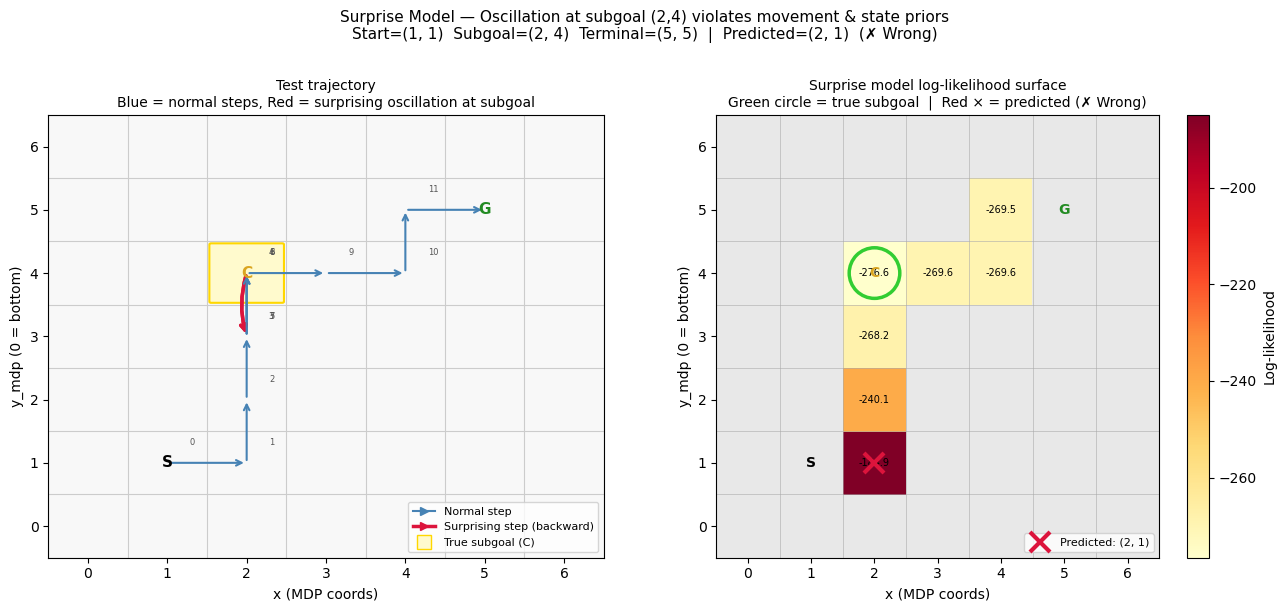

In [5]:
# ── Plot ──────────────────────────────────────────────────────────────────────
#
# Left panel : gridworld with trajectory
#   - Normal steps: orange path
#   - Surprising steps (backward at subgoal): red arrows
#   - Markers: S (start), C (coin/subgoal), G (terminal)
#
# Right panel: log-likelihood heatmap over active candidate cells
#   - Green circle = true subgoal, red X = predicted subgoal

fig, (ax_traj, ax_ll) = plt.subplots(1, 2, figsize=(13, 6))


# ── Left: trajectory ──────────────────────────────────────────────────────────

# Background grid
ax_traj.set_facecolor('#f8f8f8')
for x in range(GRID_SIZE + 1):
    ax_traj.axvline(x - 0.5, color='#cccccc', lw=0.8)
for y in range(GRID_SIZE + 1):
    ax_traj.axhline(y - 0.5, color='#cccccc', lw=0.8)

# Highlight subgoal cell
ax_traj.add_patch(mpatches.FancyBboxPatch(
    (SUBGOAL[0] - 0.45, SUBGOAL[1] - 0.45), 0.9, 0.9,
    boxstyle='round,pad=0.02', facecolor='#fffacd', edgecolor='gold', lw=1.5, zorder=1
))

# Build full position list (including final position after last action)
positions = [pos for pos, _ in TRAJECTORY]
dx, dy = ACTION_DELTA[TRAJECTORY[-1][1]]
last_pos = (positions[-1][0] + dx, positions[-1][1] + dy)
positions.append(last_pos)

# Classify each step
normal_xs, normal_ys   = [], []
for i, (pos, act) in enumerate(TRAJECTORY):
    dx, dy = ACTION_DELTA[act]
    nxt = (pos[0] + dx, pos[1] + dy)
    color = 'crimson' if i in SURPRISING_STEPS else 'steelblue'
    lw    = 2.5      if i in SURPRISING_STEPS else 1.5
    ax_traj.annotate(
        '', xy=(nxt[0], nxt[1]), xytext=(pos[0], pos[1]),
        arrowprops=dict(
            arrowstyle='->', color=color, lw=lw,
            connectionstyle='arc3,rad=0.15' if i in SURPRISING_STEPS else 'arc3,rad=0.0'
        ),
        zorder=4
    )

# Step index labels
for i, (pos, _) in enumerate(TRAJECTORY):
    ax_traj.text(pos[0] + 0.28, pos[1] + 0.28, str(i),
                 fontsize=6, color='#555', zorder=5)

# Cell labels: S, C, G
for (x, y), label, color, size in [
    (START,    'S', 'black',      11),
    (SUBGOAL,  'C', 'goldenrod',  11),
    (TERMINAL, 'G', 'forestgreen',11),
]:
    ax_traj.text(x, y, label, ha='center', va='center',
                 fontsize=size, fontweight='bold', color=color, zorder=6)

# Legend
ax_traj.plot([], [], '->', color='steelblue',  lw=1.5, label='Normal step')
ax_traj.plot([], [], '->', color='crimson',    lw=2.5, label='Surprising step (backward)')
ax_traj.plot([], [], 's',  color='#fffacd',   ms=10, mec='gold', label='True subgoal (C)')
ax_traj.legend(fontsize=8, loc='lower right')

ax_traj.set_xlim(-0.5, GRID_SIZE - 0.5)
ax_traj.set_ylim(-0.5, GRID_SIZE - 0.5)
ax_traj.set_xticks(range(GRID_SIZE))
ax_traj.set_yticks(range(GRID_SIZE))
ax_traj.set_xlabel('x (MDP coords)')
ax_traj.set_ylabel('y_mdp (0 = bottom)')
ax_traj.set_title(
    'Test trajectory\n'
    'Blue = normal steps, Red = surprising oscillation at subgoal',
    fontsize=10
)


# ── Right: log-likelihood heatmap ─────────────────────────────────────────────

# Mask non-candidate/non-visited cells
display = ll_grid.copy()   # shape (grid_size, grid_size), ll_grid[y][x]

# Only active candidates have finite values; everything else stays NaN
masked = np.ma.masked_invalid(display)

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad('#e8e8e8')

# imshow: origin='lower' so y=0 stays at bottom (matches MDP y axis)
im = ax_ll.imshow(masked, origin='lower', cmap=cmap,
                  interpolation='nearest', aspect='equal')
plt.colorbar(im, ax=ax_ll, label='Log-likelihood', fraction=0.046)

# Grid lines
for x in range(GRID_SIZE + 1):
    ax_ll.axvline(x - 0.5, color='#aaa', lw=0.4)
for y in range(GRID_SIZE + 1):
    ax_ll.axhline(y - 0.5, color='#aaa', lw=0.4)

# Annotate cell values for active candidates
for c in active:
    ll = ll_grid[c[1], c[0]]
    ax_ll.text(c[0], c[1], f'{ll:.1f}', ha='center', va='center',
               fontsize=7, color='black', zorder=5)

# Markers: S, C, G cell labels
for (x, y), label, color in [
    (START,    'S', 'black'),
    (SUBGOAL,  'C', 'goldenrod'),
    (TERMINAL, 'G', 'forestgreen'),
]:
    ax_ll.text(x, y, label, ha='center', va='center',
               fontsize=10, fontweight='bold', color=color, zorder=6)

# True subgoal: green circle
ax_ll.add_patch(mpatches.Circle(
    (SUBGOAL[0], SUBGOAL[1]), 0.4,
    fill=False, edgecolor='limegreen', lw=2.5, zorder=7
))

# Predicted subgoal: red X
ax_ll.plot(predicted[0], predicted[1], 'x',
           color='crimson', ms=14, mew=3, zorder=8,
           label=f'Predicted: {predicted}')

ax_ll.set_xticks(range(GRID_SIZE))
ax_ll.set_yticks(range(GRID_SIZE))
ax_ll.set_xlabel('x (MDP coords)')
ax_ll.set_ylabel('y_mdp (0 = bottom)')
correct_str = '✓ Correct' if predicted == SUBGOAL else '✗ Wrong'
ax_ll.set_title(
    f'Surprise model log-likelihood surface\n'
    f'Green circle = true subgoal  |  Red × = predicted ({correct_str})',
    fontsize=10
)
ax_ll.legend(fontsize=8, loc='lower right')

fig.suptitle(
    'Surprise Model — Oscillation at subgoal (2,4) violates movement & state priors\n'
    f'Start={START}  Subgoal={SUBGOAL}  Terminal={TERMINAL}  |  '
    f'Predicted={predicted}  ({correct_str})',
    fontsize=11, y=1.01
)
fig.tight_layout()
plt.show()

In [7]:
# ── Per-step log-likelihood breakdown ─────────────────────────────────────────
#
# Compare the true subgoal vs the next-best candidate step-by-step to show
# exactly where the surprising steps contribute the most signal.

next_best = active[1] if len(active) > 1 else None

print(f'Step-by-step log-likelihoods: true subgoal {SUBGOAL} vs next-best {next_best}')
print()
print(f'  {"Step":>4}  {"Pos":<10}  {"Act"}  {"Surprising?":<14}  '
      f'{"ll(true)":>10}  {"ll(next)":>10}  {"Δ":>8}')
print('  ' + '-'*72)

from surprise_v1 import surprise_likelihood

cumulative_true, cumulative_next = 0.0, 0.0
for step, (pos, act) in enumerate(TRAJECTORY):
    prev = TRAJECTORY[step - 1][1] if step > 0 else None
    ll_true = surprise_likelihood(act, pos, prev, SUBGOAL, TERMINAL,
                                  DEFAULT_PARAMS, GRID_SIZE, step)
    ll_next = surprise_likelihood(act, pos, prev, next_best, TERMINAL,
                                  DEFAULT_PARAMS, GRID_SIZE, step) if next_best else float('nan')
    cumulative_true += ll_true
    cumulative_next += ll_next
    flag = '← SURPRISING' if step in SURPRISING_STEPS else ''
    print(f'  {step:>4}  {str(pos):<10}  {act}    {flag:<14}  '
          f'{ll_true:>10.3f}  {ll_next:>10.3f}  {ll_true - ll_next:>8.3f}')

print('  ' + '-'*72)
print(f'  {"Total":<27}               {cumulative_true:>10.3f}  {cumulative_next:>10.3f}  '
      f'{cumulative_true - cumulative_next:>8.3f}')
print()
print('The largest Δ values occur at the surprising (backward) steps,')
print('confirming that oscillation at the true subgoal drives the inference.')

Step-by-step log-likelihoods: true subgoal (2, 4) vs next-best (2, 2)

  Step  Pos         Act  Surprising?       ll(true)    ll(next)         Δ
  ------------------------------------------------------------------------
     0  (1, 1)      E                      -115.778    -115.778     0.000
     1  (2, 1)      N                       -65.966     -65.966    -0.000
     2  (2, 2)      N                       -59.448     -35.858   -23.589
     3  (2, 3)      N                       -25.079     -11.046   -14.033
     4  (2, 4)      S    ← SURPRISING        -0.455      -2.389     1.934
     5  (2, 3)      N                        -1.802      -0.873    -0.929
     6  (2, 4)      S    ← SURPRISING        -1.111      -1.452     0.341
     7  (2, 3)      N                        -1.420      -1.251    -0.169
     8  (2, 4)      E                        -1.366      -1.356    -0.010
     9  (3, 4)      E                        -1.413      -1.401    -0.012
    10  (4, 4)      N                   

---

## Surprise v2 — Terminal-directed model

Instead of evaluating each candidate cell as a potential subgoal, v2 asks:
**"at which cell did the agent act most surprisingly, given it should be heading to the known terminal goal?"**

For each step `(pos, action)`, Shannon surprise is `h = −log₂ p(action | pos, prev_action, terminal_goal)` using the same combined prior (movement × state), but the state prior is always directed at the **terminal**, not a candidate subgoal. Surprise is accumulated per visited cell; the cell with the highest total surprise is the predicted subgoal.

**Key difference from v1:** The state prior is fixed toward the terminal. High surprise at a cell means the agent deviated from efficient terminal-directed navigation — a signal it stopped there for another reason (i.e. a subgoal).

In [8]:
# ── Run surprise v2 ───────────────────────────────────────────────────────────

from surprise_v2 import (
    infer_subgoal_v2,
    trajectory_surprise,
    step_surprise,
    DEFAULT_PARAMS as DEFAULT_PARAMS_V2,
)

score_grid, predicted_v2 = infer_subgoal_v2(
    trajectories=[TRAJECTORY],
    terminal_goal=TERMINAL,
    params=DEFAULT_PARAMS_V2,
    grid_size=GRID_SIZE,
    exclude={START, TERMINAL},
)

# Rank visited cells by surprise score
visited = sorted(
    {pos for pos, _ in TRAJECTORY} - {START, TERMINAL},
    key=lambda c: -score_grid[c[1], c[0]]
)

print(f'Predicted subgoal : {predicted_v2}')
print(f'True subgoal      : {SUBGOAL}')
print(f'Correct           : {predicted_v2 == SUBGOAL}')
print()
print('Per-cell surprise scores (visited cells, ranked):')
print(f'  {"Cell":<12}  {"Total surprise (bits)":>22}  Note')
for c in visited:
    sc = score_grid[c[1], c[0]]
    note = '<-- TRUE SUBGOAL' if c == SUBGOAL else ('<-- PREDICTED' if c == predicted_v2 else '')
    print(f'  {str(c):<12}  {sc:>22.3f}  {note}')

print()
print('Per-step surprise breakdown:')
print(f'  {"Step":>4}  {"Pos":<10}  {"Act"}  {"Surprising?":<14}  {"h (bits)":>10}')
print('  ' + '-'*55)
per_step_scores = trajectory_surprise(TRAJECTORY, TERMINAL, DEFAULT_PARAMS_V2, GRID_SIZE)
for step, (pos, act) in enumerate(TRAJECTORY):
    prev = TRAJECTORY[step - 1][1] if step > 0 else None
    h = step_surprise(act, pos, prev, TERMINAL, DEFAULT_PARAMS_V2, GRID_SIZE)
    flag = '← SURPRISING' if step in SURPRISING_STEPS else ''
    print(f'  {step:>4}  {str(pos):<10}  {act}    {flag:<14}  {h:>10.3f}')

Predicted subgoal : (2, 4)
True subgoal      : (2, 4)
Correct           : True

Per-cell surprise scores (visited cells, ranked):
  Cell           Total surprise (bits)  Note
  (2, 4)                        12.151  <-- TRUE SUBGOAL
  (2, 3)                         4.880  
  (4, 4)                         2.531  
  (2, 1)                         2.531  
  (4, 5)                         1.468  
  (3, 4)                         0.434  
  (2, 2)                         0.434  

Per-step surprise breakdown:
  Step  Pos         Act  Surprising?       h (bits)
  -------------------------------------------------------
     0  (1, 1)      E                         1.373
     1  (2, 1)      N                         2.531
     2  (2, 2)      N                         0.434
     3  (2, 3)      N                         0.434
     4  (2, 4)      S    ← SURPRISING         4.810
     5  (2, 3)      N                         2.223
     6  (2, 4)      S    ← SURPRISING         4.810
     7  (2, 3)    

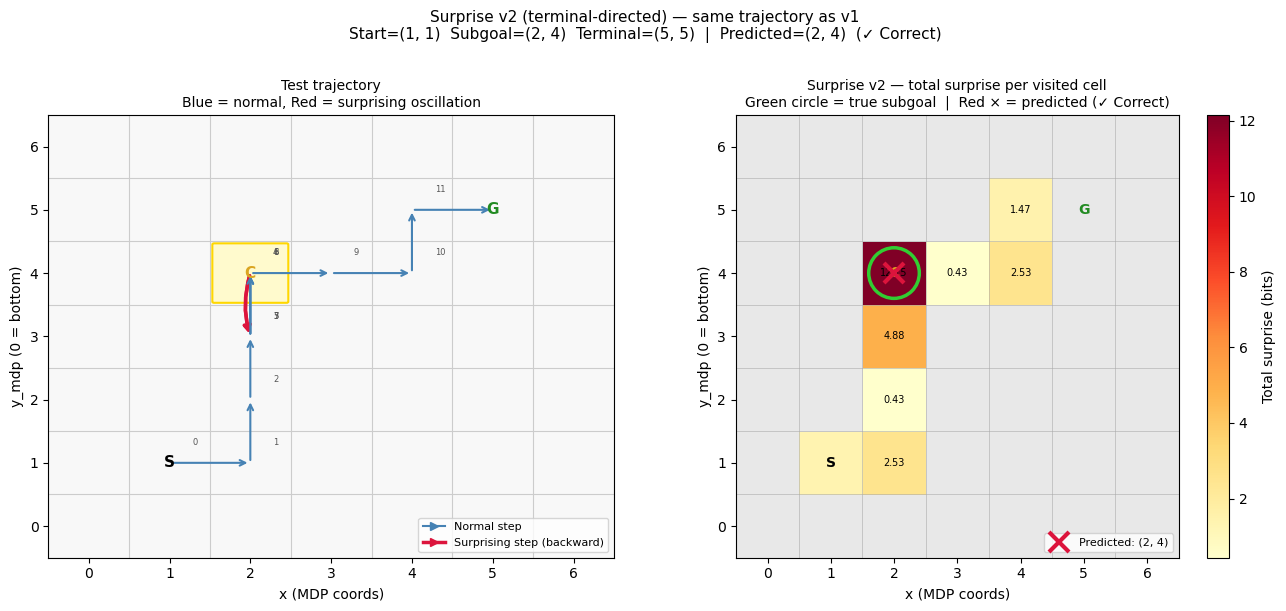

In [9]:
# ── Plot v2 ───────────────────────────────────────────────────────────────────
#
# Left panel : same trajectory diagram (reused from v1 section)
# Right panel: surprise score heatmap over visited cells
#   - Green circle = true subgoal, red X = predicted subgoal
#   - Annotated with total surprise in bits

fig, (ax_traj, ax_sc) = plt.subplots(1, 2, figsize=(13, 6))


# ── Left: trajectory (same as v1 panel) ──────────────────────────────────────

ax_traj.set_facecolor('#f8f8f8')
for x in range(GRID_SIZE + 1):
    ax_traj.axvline(x - 0.5, color='#cccccc', lw=0.8)
for y in range(GRID_SIZE + 1):
    ax_traj.axhline(y - 0.5, color='#cccccc', lw=0.8)

ax_traj.add_patch(mpatches.FancyBboxPatch(
    (SUBGOAL[0] - 0.45, SUBGOAL[1] - 0.45), 0.9, 0.9,
    boxstyle='round,pad=0.02', facecolor='#fffacd', edgecolor='gold', lw=1.5, zorder=1
))

for i, (pos, act) in enumerate(TRAJECTORY):
    from surprise_v1 import ACTION_DELTA as AD
    dx_a, dy_a = AD[act]
    nxt = (pos[0] + dx_a, pos[1] + dy_a)
    color = 'crimson' if i in SURPRISING_STEPS else 'steelblue'
    lw    = 2.5      if i in SURPRISING_STEPS else 1.5
    ax_traj.annotate(
        '', xy=(nxt[0], nxt[1]), xytext=(pos[0], pos[1]),
        arrowprops=dict(
            arrowstyle='->', color=color, lw=lw,
            connectionstyle='arc3,rad=0.15' if i in SURPRISING_STEPS else 'arc3,rad=0.0'
        ),
        zorder=4
    )
    ax_traj.text(pos[0] + 0.28, pos[1] + 0.28, str(i),
                 fontsize=6, color='#555', zorder=5)

for (x, y), label, color, size in [
    (START,    'S', 'black',       11),
    (SUBGOAL,  'C', 'goldenrod',   11),
    (TERMINAL, 'G', 'forestgreen', 11),
]:
    ax_traj.text(x, y, label, ha='center', va='center',
                 fontsize=size, fontweight='bold', color=color, zorder=6)

ax_traj.plot([], [], '->', color='steelblue', lw=1.5, label='Normal step')
ax_traj.plot([], [], '->', color='crimson',   lw=2.5, label='Surprising step (backward)')
ax_traj.legend(fontsize=8, loc='lower right')
ax_traj.set_xlim(-0.5, GRID_SIZE - 0.5)
ax_traj.set_ylim(-0.5, GRID_SIZE - 0.5)
ax_traj.set_xticks(range(GRID_SIZE))
ax_traj.set_yticks(range(GRID_SIZE))
ax_traj.set_xlabel('x (MDP coords)')
ax_traj.set_ylabel('y_mdp (0 = bottom)')
ax_traj.set_title('Test trajectory\nBlue = normal, Red = surprising oscillation', fontsize=10)


# ── Right: surprise score heatmap ─────────────────────────────────────────────

masked_sc = np.ma.masked_invalid(score_grid)
cmap_sc = plt.cm.YlOrRd.copy()
cmap_sc.set_bad('#e8e8e8')

im = ax_sc.imshow(masked_sc, origin='lower', cmap=cmap_sc,
                  interpolation='nearest', aspect='equal')
plt.colorbar(im, ax=ax_sc, label='Total surprise (bits)', fraction=0.046)

for x in range(GRID_SIZE + 1):
    ax_sc.axvline(x - 0.5, color='#aaa', lw=0.4)
for y in range(GRID_SIZE + 1):
    ax_sc.axhline(y - 0.5, color='#aaa', lw=0.4)

# Annotate visited cells with their surprise score
for c in visited:
    sc = score_grid[c[1], c[0]]
    ax_sc.text(c[0], c[1], f'{sc:.2f}', ha='center', va='center',
               fontsize=7, color='black', zorder=5)

# Cell labels: S, C, G
for (x, y), label, color in [
    (START,    'S', 'black'),
    (SUBGOAL,  'C', 'goldenrod'),
    (TERMINAL, 'G', 'forestgreen'),
]:
    ax_sc.text(x, y, label, ha='center', va='center',
               fontsize=10, fontweight='bold', color=color, zorder=6)

# True subgoal: green circle
ax_sc.add_patch(mpatches.Circle(
    (SUBGOAL[0], SUBGOAL[1]), 0.4,
    fill=False, edgecolor='limegreen', lw=2.5, zorder=7
))

# Predicted: red X
ax_sc.plot(predicted_v2[0], predicted_v2[1], 'x',
           color='crimson', ms=14, mew=3, zorder=8,
           label=f'Predicted: {predicted_v2}')

ax_sc.set_xticks(range(GRID_SIZE))
ax_sc.set_yticks(range(GRID_SIZE))
ax_sc.set_xlabel('x (MDP coords)')
ax_sc.set_ylabel('y_mdp (0 = bottom)')
correct_str_v2 = '✓ Correct' if predicted_v2 == SUBGOAL else '✗ Wrong'
ax_sc.set_title(
    f'Surprise v2 — total surprise per visited cell\n'
    f'Green circle = true subgoal  |  Red × = predicted ({correct_str_v2})',
    fontsize=10
)
ax_sc.legend(fontsize=8, loc='lower right')

fig.suptitle(
    'Surprise v2 (terminal-directed) — same trajectory as v1\n'
    f'Start={START}  Subgoal={SUBGOAL}  Terminal={TERMINAL}  |  '
    f'Predicted={predicted_v2}  ({correct_str_v2})',
    fontsize=11, y=1.01
)
fig.tight_layout()
plt.show()